# Spatial matched-filter beamforming for microbeamforming arrays

This notebook reproduces the imaging results in:

> Verhoef L., Kruizinga P., Voorneveld J. **Four-dimensional ultrasound imaging
> with microbeamforming arrays.** *TODO: Update once published.

Given a preprocessed acquisition (`.h5`) it computes the matched-filter image
volume and writes the result back as another `.h5`, with optional `.vts`/`.pvd`
exports for ParaView.

The example data are published on Zenodo at
[10.5281/zenodo.20158128](https://doi.org/10.5281/zenodo.20158128). Download the three zip files from Zenodo and unzip
them into the `./data/` folder so the directory tree looks like:

```
data/
├── SpinningDisk/
│   ├── widebeam_<speed_mm/s>.h5
│   └── encoded_<speed_mm/s>.h5
├── PigLiver/
│   ├── widebeam.h5
│   └── encoded.h5
└── HumanBrain/
    ├── widebeam.h5
    └── encoded.h5
```

The output will be structured as follows:

```
results/
├── SpinningDisk/
│   ├── <sequence>_<speed>_beamformed.h5           ← beamformed image data
│   ├── <sequence>_<speed>_beamformed.pvd          ← ParaView collection (if save_vtk=True)
│   └── <sequence>_<speed>_beamformed/             ← per-frame VTK files  (if save_vtk=True)
│       └── frame_NNNN.vts
├── PigLiver/
│   └── ...                                        ← same structure; suffix is _beamformed_svd
│                                                     when tissue_cutoff is set
└── HumanBrain/
    └── ...
```

Each `.h5` output file contains:

| Dataset / Attribute | Description |
|---|---|
| `beamformed_data` | Beamformed frames `(n_frames, n_voxels)` — `complex64` IQ when `save_iq=True`, `float32` envelope when `save_iq=False` |
| `grid/points_cartesian` | Cartesian voxel positions `(n_rho, n_phi, n_theta, 3)` in metres |
| attributes | `image_size`, `num_frames`, `theta/phi/rho_range_deg/m`, `sound_speed_m_s`, `sampling/demod/center_frequency_hz`, `whiten_method`, `tissue_cutoff`, `datatype`, `source_file` |

> **Hardware:** an NVIDIA GPU with CUDA and a recent CuPy build is recommended.


In [1]:
from __future__ import annotations
import numpy as np
from numpy.typing import ArrayLike
import cupy as cp
import scipy as sp
import tqdm
import vtk
import vtk.util.numpy_support as numpy_support
import h5py
from pathlib import Path

In [2]:
# ── Test that data is available and structured correctly ─────────────────────
# Download the three zip files from Zenodo (10.5281/zenodo.20158128) and unzip
# them into the ./data/ folder so the directory tree looks like:
#
#   data/
#   ├── SpinningDisk/
#   │   ├── widebeam_<speed_mm/s>.h5
#   │   └── encoded_<speed_mm/s>.h5
#   ├── PigLiver/
#   │   ├── widebeam.h5
#   │   └── encoded.h5
#   └── HumanBrain/
#       ├── widebeam.h5
#       └── encoded.h5
#
# No download is performed here; the processing cell below will raise a
# FileNotFoundError with a descriptive message if the requested file is missing.

from pathlib import Path

DATA_ROOT = Path("./data")

# Map (dataset, sequence_type, speed) → relative path inside DATA_ROOT.
DATA_MANIFEST = {
    ("SpinningDisk", "widebeam", "0"):    "SpinningDisk/widebeam_0.h5",
    ("SpinningDisk", "encoded",  "0"):    "SpinningDisk/encoded_0.h5",
    ("SpinningDisk", "widebeam", "10"):   "SpinningDisk/widebeam_10.h5",
    ("SpinningDisk", "encoded",  "10"):   "SpinningDisk/encoded_10.h5",
    ("SpinningDisk", "widebeam", "100"):  "SpinningDisk/widebeam_100.h5",
    ("SpinningDisk", "encoded",  "100"):  "SpinningDisk/encoded_100.h5",
    ("SpinningDisk", "widebeam", "300"):  "SpinningDisk/widebeam_300.h5",
    ("SpinningDisk", "encoded",  "300"):  "SpinningDisk/encoded_300.h5",
    ("SpinningDisk", "widebeam", "1000"): "SpinningDisk/widebeam_1000.h5",
    ("SpinningDisk", "encoded",  "1000"): "SpinningDisk/encoded_1000.h5",
    ("PigLiver",     "widebeam", None):   "PigLiver/widebeam.h5",
    ("PigLiver",     "encoded",  None):   "PigLiver/encoded.h5",
    ("HumanBrain",   "widebeam", None):   "HumanBrain/widebeam.h5",
    ("HumanBrain",   "encoded",  None):   "HumanBrain/encoded.h5",
}

print("Available datasets:")
for k, v in DATA_MANIFEST.items():
    status = "✓ (available)" if (DATA_ROOT / v).exists() else "✗ (missing)"
    print(f"  {k}  →  {DATA_ROOT / v}  {status}")


Available datasets:
  ('SpinningDisk', 'widebeam', '0')  →  data/SpinningDisk/widebeam_0.h5  ✓ (available)
  ('SpinningDisk', 'encoded', '0')  →  data/SpinningDisk/encoded_0.h5  ✓ (available)
  ('SpinningDisk', 'widebeam', '10')  →  data/SpinningDisk/widebeam_10.h5  ✓ (available)
  ('SpinningDisk', 'encoded', '10')  →  data/SpinningDisk/encoded_10.h5  ✓ (available)
  ('SpinningDisk', 'widebeam', '100')  →  data/SpinningDisk/widebeam_100.h5  ✓ (available)
  ('SpinningDisk', 'encoded', '100')  →  data/SpinningDisk/encoded_100.h5  ✓ (available)
  ('SpinningDisk', 'widebeam', '300')  →  data/SpinningDisk/widebeam_300.h5  ✓ (available)
  ('SpinningDisk', 'encoded', '300')  →  data/SpinningDisk/encoded_300.h5  ✓ (available)
  ('SpinningDisk', 'widebeam', '1000')  →  data/SpinningDisk/widebeam_1000.h5  ✓ (available)
  ('SpinningDisk', 'encoded', '1000')  →  data/SpinningDisk/encoded_1000.h5  ✓ (available)
  ('PigLiver', 'widebeam', None)  →  data/PigLiver/widebeam.h5  ✓ (available)
  ('PigLiv

In [3]:
def whiten_ubf(
    y: ArrayLike,
    frequency: ArrayLike,
    receive_delay: ArrayLike,
    receive_apod: ArrayLike | None = None,
    impulse_response: ArrayLike | None = None,
    mode: str = "diag",
    device: str | None = None,
) -> np.ndarray:
    """Whiten microbeamformed data prior to matched filtering.

    Computes the microbeamforming weight matrix V_q per frequency and uses it to
    pre-whiten y so that transmit events contribute equally to the matched filter.

    Args:
        y complex (..., n_subapertures, n_transmits, n_freqs): microbeamformed sensor data in the frequency domain.
        frequency real (n_freqs,): frequencies corresponding to the last axis of y.
        receive_delay real (n_transmits, n_subapertures, subap_size): microbeamforming delay vectors.
        receive_apod real (n_transmits, n_subapertures, subap_size): microbeamforming apodization (ones if None).
        impulse_response complex (n_freqs,): frequency response of the array (ones if None).
        mode: 'diag', 'eigen', or 'cholesky'.
            'diag': scales each (n_freqs, n_transmits, n_subapertures) entry by the inverse RMS energy of the
                microbeamforming weights. Safe default; rarely changes the result
                up to a scalar.
            'eigen': applies vvh^{-1/2} across transmit events n_transmits via eigendecomposition.
                Assumes the true image and transmit are approximately constant across
                events.
            'cholesky': same assumption as 'eigen' but uses a Cholesky solve instead,
                which can be more stable when v is close to unitary.
        device: None, 'cpu' or 'cuda'. Inferred from y if None.

    Returns:
        y_whitened complex (..., n_subapertures, n_transmits, n_freqs): whitened data as a numpy array.
    """
    if device == "cpu":
        xp = np
    elif device == "cuda":
        xp = cp
    elif device is None:
        xp = cp.get_array_module(y)
    else:
        raise ValueError(f"unknown device: '{device}'")

    y = xp.asarray(y, dtype=np.complex64)
    frequency = xp.asarray(frequency, dtype=np.float32)
    receive_delay = xp.asarray(receive_delay, dtype=np.float32)

    (n_subapertures, n_transmits, n_freqs) = y.shape[-3:]

    if receive_apod is not None:
        receive_apod = xp.asarray(receive_apod, dtype=np.float32)
    else:
        receive_apod = xp.ones_like(receive_delay)

    if impulse_response is not None:
        impulse_response = xp.asarray(impulse_response, dtype=np.complex64)
    else:
        impulse_response = xp.ones(n_freqs, dtype=np.complex64)

    # v[n_freqs, n_transmits, n_subapertures, subap_size] = H[k] * b[q,s,l] * exp(-2pi i f[k] tau[q,s,l])
    v = impulse_response[:, None, None, None] * receive_apod * xp.exp(
        -2j * np.pi * frequency[:, None, None, None] * receive_delay
    )  # (n_freqs, n_transmits, n_subapertures, subap_size)

    if mode == "eigen":
        vvh = xp.einsum("kqsl,kpsl->ksqp", v, v.conj())  # (n_freqs, n_subapertures, n_transmits, n_transmits)
        vvh = 0.5 * (vvh + vvh.swapaxes(-2, -1).conj())
        evals, evecs = xp.linalg.eigh(vvh)
        evals = xp.maximum(evals, 1e-12)
        # w[n_freqs, q_out, n_subapertures, q_in] = vvh^{-1/2}
        w = xp.einsum("ksql,ksl,kspl->kqsp", evecs, 1.0 / xp.sqrt(evals), evecs.conj(), optimize=True)
        y = xp.einsum("kqsp,...spk->...sqk", w, y)

    elif mode == "cholesky":
        vvh = xp.einsum("kqsl,kpsl->ksqp", v, v.conj())  # (n_freqs, n_subapertures, n_transmits, n_transmits)
        vvh = 0.5 * (vvh + vvh.swapaxes(-2, -1).conj())
        ident = xp.eye(n_transmits, dtype=vvh.dtype)[None, None, :, :]
        ltri = xp.linalg.cholesky(vvh + 1e-6 * ident)  # (n_freqs, n_subapertures, n_transmits, n_transmits)

        # reshape to (n_freqs, n_subapertures, batch, n_transmits) so linalg.solve can broadcast
        batch_shape = y.shape[:-3]
        batch = int(np.prod(batch_shape)) if batch_shape else 1
        y_rs = xp.moveaxis(y, -1, 0).reshape(n_freqs, batch, n_subapertures, n_transmits)
        y_rs = y_rs.transpose(0, 2, 1, 3)                      # (n_freqs, n_subapertures, batch, n_transmits)
        # expand ltri to (n_freqs, n_subapertures, batch, n_transmits, n_transmits) — cupy.linalg.solve
        # does not support broadcasting across batch dimensions, so we must materialize it explicitly
        ltri_b = xp.ascontiguousarray(
            xp.broadcast_to(ltri[:, :, None, :, :], (n_freqs, n_subapertures, batch, n_transmits, n_transmits))
        )
        y_rs = xp.linalg.solve(ltri_b, y_rs[..., None]).squeeze(-1)
        y_rs = y_rs.transpose(0, 2, 1, 3).reshape(n_freqs, *batch_shape, n_subapertures, n_transmits)
        y = xp.moveaxis(y_rs, 0, -1)                           # (..., n_subapertures, n_transmits, n_freqs)

    elif mode == "diag":
        vvh = xp.einsum("kqsl,kqsl->kqs", v, v.conj())  # (n_freqs, n_transmits, n_subapertures)
        vvh = xp.maximum(vvh, 1e-12)
        w = 1.0 / xp.sqrt(vvh)
        y = xp.einsum("kqs,...sqk->...sqk", w, y)

    else:
        raise ValueError(f"unknown whitening mode: '{mode}'. Expected 'diag', 'eigen' or 'cholesky'.")

    return cp.asnumpy(y) if xp is cp else np.asarray(y)

def matched_filter_ubf(
    y: ArrayLike,
    xpos: ArrayLike,
    ypos: ArrayLike,
    frequency: ArrayLike,
    sound_speed: ArrayLike,
    transmit_delay: ArrayLike,
    receive_delay: ArrayLike,
    transmit_apod=None,
    receive_apod=None,
    impulse_response: ArrayLike | None = None,
    batchsize: int | tuple = 65536,
    progress: bool = True,
    device: str | None = None,
):
    """Compute the matched filter of microbeamformed data (per-frequency).

    Evaluates: x_est = sum_q (T_q^H R^H V_q^H y_q), where:
        T_q[n,m] = R[n,m] * a_q[m] * exp(-2pi i f t_q[m])   (transmit field)
        V_q = blkdiag(V_q1,...,V_qs),  V_qs[l] = b_qs[l] * exp(-2pi i f v_qs[l])

    To apply whitening, call whiten_ubf(y, ...) before this function and pass
    the result as y.

    Args:
        y complex (..., n_subapertures, n_transmits, n_freqs): microbeamformed sensor data in frequency domain.
        xpos real (n_voxels, 3): voxel positions.
        ypos real (n_elements, 3): sensor positions.
        frequency real (n_freqs,): frequencies corresponding to the last axis of y.
        sound_speed real: sound speed in m/s.
        transmit_delay real (n_transmits, n_elements): transmit delay vectors.
        receive_delay real (n_transmits, n_subapertures, subap_size): microbeamforming delay vectors.
        transmit_apod real (n_transmits, n_elements): transmit apodization (ones if None).
        receive_apod real (n_transmits, n_subapertures, subap_size): microbeamforming apodization (ones if None).
        impulse_response complex (n_freqs,): frequency response of the array (ones if None).
        batchsize int or (int, int): voxel batch size, or (n_batch, k_batch).
        progress: display a tqdm progress bar.
        device: None, 'cpu' or 'cuda'. Inferred from y if None.

    Returns:
        x_est complex (..., n_voxels): image estimate as a numpy array.

    
    """
    if device == "cpu":
        xp = np
    elif device == "cuda":
        xp = cp
    elif device is None:
        xp = cp.get_array_module(y)
    else:
        raise ValueError(f"unknown device: '{device}'")

    xpos = xp.asarray(xpos, dtype=np.float32)
    ypos = xp.asarray(ypos, dtype=np.float32)

    assert len(xpos.shape) == 2 and xpos.shape[1] == 3, f"invalid shape for xpos: {xpos.shape}, (expected [:, 3])"
    assert len(ypos.shape) == 2 and ypos.shape[1] == 3, f"invalid shape for ypos: {ypos.shape}, (expected [:, 3])"

    n_voxels   = xpos.shape[0]
    n_elements = ypos.shape[0]

    y = xp.asarray(y, dtype=np.complex64)
    (n_subapertures, n_transmits, n_freqs) = y.shape[-3:]

    # move frequencies to the first axis for more efficient batching
    y = xp.ascontiguousarray(xp.moveaxis(y, -1, 0).reshape(n_freqs, -1, n_subapertures, n_transmits))
    batch = y.shape[1]

    frequency = xp.asarray(frequency, dtype=np.float32)
    transmit_delay = xp.asarray(transmit_delay, dtype=np.float32)
    receive_delay = xp.asarray(receive_delay, dtype=np.float32)

    subap_size = receive_delay.shape[-1]

    if transmit_apod is not None:
        transmit_apod = xp.asarray(transmit_apod, dtype=np.float32)
    else:
        transmit_apod = xp.ones_like(transmit_delay, dtype=np.float32)

    if receive_apod is not None:
        receive_apod = xp.asarray(receive_apod, dtype=np.float32)
    else:
        receive_apod = xp.ones_like(receive_delay, dtype=np.float32)

    if impulse_response is not None:
        impulse_response = xp.asarray(impulse_response, dtype=np.complex64)
    else:
        impulse_response = xp.ones(n_freqs, dtype=np.complex64)

    assert n_elements == n_subapertures * subap_size, \
        f"total sensors {n_elements} must equal n_subapertures*subap_size={n_subapertures*subap_size}"
    assert len(frequency.shape) == 1 and len(frequency) == n_freqs, \
        f"invalid shape for frequency: {frequency.shape}"
    assert transmit_delay.shape == (n_transmits, n_elements), \
        f"invalid shape for transmit_delay: {transmit_delay.shape}, expected ({n_transmits}, {n_elements})"
    assert transmit_apod.shape == (n_transmits, n_elements), \
        f"invalid shape for transmit_apod: {transmit_apod.shape}, expected ({n_transmits}, {n_elements})"
    assert receive_delay.shape[0] == n_transmits and receive_delay.shape[1] == n_subapertures, \
        f"invalid shape for receive_delay: {receive_delay.shape}, expected ({n_transmits}, {n_subapertures}, {subap_size})"
    assert receive_apod.shape == (n_transmits, n_subapertures, subap_size), \
        f"invalid shape for receive_apod: {receive_apod.shape}, expected ({n_transmits}, {n_subapertures}, {subap_size})"
    assert len(impulse_response.shape) == 1 and len(impulse_response) == n_freqs, \
        f"invalid shape for impulse_response: {impulse_response.shape}"

    if isinstance(batchsize, int):
        batchsize = (batchsize, 1)
    elif isinstance(batchsize, (tuple, list)) and len(batchsize) == 2:
        if not isinstance(batchsize[0], int) and isinstance(batchsize[1], int):
            raise ValueError(f"invalid batchsize: {batchsize}")
    else:
        raise ValueError(f"invalid batchsize: {batchsize}")

    out = np.zeros((batch, n_voxels), dtype=np.complex64)

    tx_field = impulse_response[:, None, None] * transmit_apod * xp.exp(
        -2j * np.pi * frequency[:, None, None] * transmit_delay
    )  # (n_freqs, n_transmits, n_elements)
    rx_field = impulse_response[:, None, None, None] * receive_apod * xp.exp(
        -2j * np.pi * frequency[:, None, None, None] * receive_delay
    )  # (n_freqs, n_transmits, n_subapertures, subap_size)

    pbar = None
    if progress:
        pbar = tqdm.tqdm(total=n_voxels * n_freqs)

    for nstart in range(0, n_voxels, batchsize[0]):
        nstop = min(nstart + batchsize[0], n_voxels)

        delay = xp.linalg.norm(xpos[nstart:nstop, None, :] - ypos, axis=-1)  # (n_voxels_batch, n_elements)
        delay = 2 * np.pi * (delay / sound_speed)  # phase delay in radians

        accum = xp.zeros((batch, nstop - nstart), dtype=out.dtype)

        for kstart in range(0, n_freqs, batchsize[1]):
            kstop = min(kstart + batchsize[1], n_freqs)

            r = xp.exp(-1j * frequency[kstart:kstop, None, None] * delay)  # (n_freqs_batch, n_voxels_batch, n_elements)

            # accum += xp.einsum(  # type: ignore
            #     "kqm,knm,knsl,kqsl,k...sq->...n",
            #     tx_field[kstart:kstop].conj(),
            #     r.conj(),
            #     r.reshape(*r.shape[:2], -1, subap_size).conj(),
            #     rx_field[kstart:kstop].conj(),
            #     y[kstart:kstop],  # type: ignore
            #     optimize=True,
            # )

            kernel = xp.einsum(  # type: ignore
                "kqm,knm,knsl,kqsl->kqsn", 
                tx_field[kstart:kstop].conj(), 
                r.conj(), 
                r.reshape(*r.shape[:2], -1, subap_size).conj(), 
                rx_field[kstart:kstop].conj(), 
                optimize=True
            )

            kernel = kernel / xp.maximum(xp.linalg.norm(kernel, axis=(1, 2), keepdims=True), 1e-9)  # type: ignore

            accum += xp.einsum(  # type: ignore
                "kqsn,k...sq->...n", 
                kernel,
                y[kstart:kstop],  # type: ignore
                optimize=True
            )

            if pbar is not None:
                pbar.update((kstop - kstart) * (nstop - nstart))

        out[:, nstart:nstop] = cp.asnumpy(accum)

    if pbar is not None:
        pbar.close()

    return out

def plot_matched_filter_fields(
    xpos: ArrayLike,
    ypos: ArrayLike,
    frequency: ArrayLike,
    sound_speed: float,
    transmit_delay: ArrayLike,
    receive_delay: ArrayLike,
    transmit_apod=None,
    receive_apod=None,
    receive_focus_delay: ArrayLike | None = None,
    imgsize: tuple | list = None,
    grid_points: np.ndarray = None,
    batchsize: int | tuple = (16384, 4),
    device: str = "cuda",
    gpu_id: int | None = None,
    plot_to: str | Path | None = None,
    waves: list | None = None,
):
    """Plot forward (transmit) and reverse (receive) field intensity per wave.

    Shows maximum intensity projections in the XZ and YZ planes.
    XZ rows are omitted when imgsize[2] (theta) == 1.
    YZ rows are omitted when imgsize[1] (phi) == 1.

    Field power is summed incoherently over frequencies (sum of |F|^2) to
    preserve frequency-dependent layer refraction while avoiding carrier fringes.

    Parameters
    ----------
    xpos : (n_voxels, 3) array
        Voxel positions in Cartesian coordinates.
    ypos : (n_elements, 3) array
        Sensor/element positions in Cartesian coordinates.
    frequency : (n_freqs,) array
        Frequency axis in Hz.
    sound_speed : float
        Sound speed in m/s.
    transmit_delay : (n_transmits, n_elements) array
        Transmit delay vectors in seconds.
    receive_delay : (n_transmits, n_subapertures, subap_size) array
        Receive (microbeamforming) delay vectors in seconds.
    transmit_apod : (n_transmits, n_elements) array or None
        Transmit apodization. Ones if None.
    receive_apod : (n_transmits, n_subapertures, subap_size) array or None
        Receive apodization. Ones if None.
    receive_focus_delay : (n_transmits, n_subapertures) array or None
        Per-subaperture receive focus delay in seconds. Applied as an additional
        phase shift exp(-2pi i f tau_focus[q, s]) to each subaperture output
        after microbeamforming. None = no additional focusing.
    imgsize : tuple of 3 ints
        Volume shape (n_rho, n_phi, n_theta).
    grid_points : (n_rho, n_phi, n_theta, 3) array
        Cartesian coordinates of every voxel (for axis labels).
    batchsize : int or (int, int)
        (voxel_batch, freq_batch) sizes for GPU computation.
    device : str
        'cuda' or 'cpu'.
    gpu_id : int or None
        GPU device index. None uses the current device.
    plot_to : str, Path, or None
        If a path, saves the figure there. If None, displays on screen.
    waves : list of int or None
        Indices of waves to compute and plot. None = all waves.

    Returns
    -------
    forward_3d : (n_waves, n_rho, n_phi, n_theta) array
        Forward (transmit) field amplitude.
    reverse_3d : (n_waves, n_rho, n_phi, n_theta) array
        Reverse (receive) field amplitude.
    """
    import matplotlib.pyplot as plt

    if gpu_id is not None:
        cp.cuda.Device(gpu_id).use()

    xp = cp if device == "cuda" else np

    xpos = xp.asarray(xpos, dtype=np.float32)
    ypos = xp.asarray(ypos, dtype=np.float32)
    frequency = xp.asarray(frequency, dtype=np.float32)
    transmit_delay = xp.asarray(transmit_delay, dtype=np.float32)
    receive_delay = xp.asarray(receive_delay, dtype=np.float32)

    # select subset of waves
    q_total = transmit_delay.shape[0]
    if waves is None:
        wave_indices = list(range(q_total))
    else:
        wave_indices = list(waves)
    transmit_delay = transmit_delay[wave_indices]
    receive_delay = receive_delay[wave_indices]

    n = xpos.shape[0]
    m = ypos.shape[0]
    q = len(wave_indices)
    k = len(frequency)
    l = receive_delay.shape[-1]
    s = m // l

    if transmit_apod is not None:
        transmit_apod = xp.asarray(transmit_apod, dtype=np.float32)[wave_indices]
    else:
        transmit_apod = xp.ones_like(transmit_delay)
    if receive_apod is not None:
        receive_apod = xp.asarray(receive_apod, dtype=np.float32)[wave_indices]
    else:
        receive_apod = xp.ones_like(receive_delay)
    if receive_focus_delay is not None:
        receive_focus_delay = xp.asarray(receive_focus_delay, dtype=np.float32)[wave_indices]  # (q, s)

    if isinstance(batchsize, int):
        batchsize = (batchsize, 1)

    # Transmit / receive weight matrices  (k, q, m) and (k, q, s, l)
    t = (transmit_apod
         * xp.exp(-2j * np.pi * frequency[:, None, None] * transmit_delay))
    v = (receive_apod
         * xp.exp(-2j * np.pi * frequency[:, None, None, None] * receive_delay))
    if receive_focus_delay is not None:
        # apply per-subaperture focus phase: (k, q, s, 1) broadcast over subap_size
        v = v * xp.exp(-2j * np.pi * frequency[:, None, None] * receive_focus_delay)[:, :, :, None]

    # Accumulate *power* (incoherent sum) over frequencies to avoid carrier
    # fringes while preserving frequency-dependent refraction through the layer.
    forward_power = np.zeros((q, n), dtype=np.float32)
    reverse_power = np.zeros((q, n), dtype=np.float32)

    for nstart in tqdm.tqdm(range(0, n, batchsize[0]), desc="Computing fields"):
        nstop = min(nstart + batchsize[0], n)
        nb = nstop - nstart

        delay = xp.linalg.norm(xpos[nstart:nstop, None, :] - ypos, axis=-1)
        delay = 2 * np.pi * (delay / sound_speed)

        fwd_pow_accum = xp.zeros((q, nb), dtype=np.float32)
        rev_pow_accum = xp.zeros((q, nb), dtype=np.float32)

        for kstart in range(0, k, batchsize[1]):
            kstop = min(kstart + batchsize[1], k)
            # Green's function  (k_batch, n_batch, m)
            r = xp.exp(-1j * frequency[kstart:kstop, None, None] * delay)

            # Forward field per frequency, accumulate |F|^2
            fwd_k = xp.einsum("kqm,knm->kqn", t[kstart:kstop], r, optimize=True)
            fwd_pow_accum += (fwd_k.real**2 + fwd_k.imag**2).sum(axis=0)

            # Reverse field per frequency, accumulate |B|^2
            r_sub = r.reshape(kstop - kstart, nb, s, l)
            rev_k = xp.einsum("kqsl,knsl->kqn", v[kstart:kstop], r_sub, optimize=True)
            rev_pow_accum += (rev_k.real**2 + rev_k.imag**2).sum(axis=0)

        if xp is cp:
            forward_power[:, nstart:nstop] = cp.asnumpy(fwd_pow_accum)
            reverse_power[:, nstart:nstop] = cp.asnumpy(rev_pow_accum)
        else:
            forward_power[:, nstart:nstop] = fwd_pow_accum
            reverse_power[:, nstart:nstop] = rev_pow_accum

    imgsize = tuple(int(v) for v in imgsize)
    forward_3d = np.sqrt(forward_power).reshape(q, *imgsize)
    reverse_3d = np.sqrt(reverse_power).reshape(q, *imgsize)

    x_mm = grid_points[..., 0] * 1e3
    y_mm = grid_points[..., 1] * 1e3
    z_mm = grid_points[..., 2] * 1e3

    show_xz = imgsize[2] > 1  # theta dimension
    show_yz = imgsize[1] > 1  # phi dimension

    # Build list of (label, data, h_coords, v_coords, xlabel, cmap) for active rows
    active_rows = []
    if show_xz:
        center_phi = imgsize[1] // 2
        xz_h = x_mm[:, center_phi, :]
        xz_v = z_mm[:, center_phi, :]
        active_rows.append(("Forward XZ", forward_3d.max(axis=2), xz_h, xz_v, "x (mm)", "hot"))
    if show_yz:
        center_theta = imgsize[2] // 2
        yz_h = y_mm[:, :, center_theta]
        yz_v = z_mm[:, :, center_theta]
        active_rows.append(("Forward YZ", forward_3d.max(axis=3), yz_h, yz_v, "y (mm)", "hot"))
    if show_xz:
        active_rows.append(("Reverse XZ", reverse_3d.max(axis=2), xz_h, xz_v, "x (mm)", "viridis"))
    if show_yz:
        active_rows.append(("Reverse YZ", reverse_3d.max(axis=3), yz_h, yz_v, "y (mm)", "viridis"))

    nrows = len(active_rows)

    fig, axes = plt.subplots(nrows, q, figsize=(3 * q, 3 * nrows), squeeze=False)

    for row_idx, (label, data, h_coords, v_coords, xlabel, cmap) in enumerate(active_rows):
        vmax = data.max()
        for qi in range(q):
            ax = axes[row_idx, qi]
            im = ax.pcolormesh(
                h_coords, v_coords, data[qi],
                shading="gouraud", cmap=cmap, vmin=0, vmax=vmax,
            )
            ax.set_aspect("equal")
            ax.invert_yaxis()
            if qi == 0:
                ax.set_ylabel(f"{label}\nz (mm)")
            else:
                ax.set_yticklabels([])
            if row_idx == nrows - 1:
                ax.set_xlabel(xlabel)
            else:
                ax.set_xticklabels([])
            if row_idx == 0:
                ax.set_title(f"Wave {wave_indices[qi]}")
        # fig.colorbar(im, ax=axes[row_idx, :].tolist(), fraction=0.02, pad=0.04)

    plt.tight_layout()
    if plot_to is not None:
        plt.savefig(str(plot_to), dpi=150, bbox_inches="tight")
        print(f"Saved field plot to: {plot_to}")
        plt.close(fig)
    else:
        plt.show()

    return forward_3d, reverse_3d

def sph2cart(theta, phi, rad):
    y = rad * np.sin(phi)

    rcoselev = rad * np.cos(phi)
    z = rcoselev * np.cos(theta)
    x = rcoselev * np.sin(theta)

    return np.stack([x, y, z])

def cart2sph(x, y, z):
    hypotxz = np.hypot(x, z)
    rad = np.hypot(hypotxz, y)
    phi = np.arctan2(y, hypotxz)
    theta = np.arctan2(x, z)
    # deal with negative z values
    phi[z<0] = np.pi - phi[z<0]
    theta[z<0] += np.pi
    return theta, phi, rad

def sphgrid(theta=None, phi=None, rho=None, theta_range=None, phi_range=None, rho_range=None, size=None, degrees=False):
    """
    Generates a spherical grid and converts it to Cartesian coordinates.
    
    Parameters:
    theta (1D array-like, optional): Array of theta values in radians.
    phi (1D array-like, optional): Array of phi values in radians.
    rho (1D array-like, optional): Array of rho values.
    theta_range (tuple, scalar, optional): Range (min, max) for theta values in degrees.
    phi_range (tuple, scalar, optional): Range (min, max) for phi values in degrees.
    rho_range (tuple, scalar, optional): Range (min, max) for rho values.
    imgsize (list, optional): List of three integers [rho_size, phi_size, theta_size] representing the grid size.
    
    Returns:
    coords (2D array): Cartesian coordinates of the grid points.
    """
    
    # Validate inputs
    if size is None and (theta is None or phi is None or rho is None):
        raise ValueError("Either imgsize with ranges or individual arrays for theta, phi, and rho must be provided.")
    
    if size is not None:
        if len(size) != 3:
            raise ValueError("imgsize must be a list of three integers.")
        
        rho_size, phi_size, theta_size = size
        
        if theta_range is not None:
            if not isinstance(theta_range, (tuple, list)) or len(theta_range) != 2:
                theta = np.asarray(theta_range).astype(np.float32)
            else:
                theta = np.linspace(theta_range[0], theta_range[1], theta_size).astype(np.float32)
        if phi_range is not None:
            if not isinstance(phi_range, (tuple, list)) or len(phi_range) != 2:
                phi = np.asarray(phi_range).astype(np.float32)
            else:
                phi = np.linspace(phi_range[0], phi_range[1], phi_size).astype(np.float32)
        if rho_range is not None:
            if not isinstance(rho_range, (tuple, list)) or len(rho_range) != 2:
                rho = np.asarray(rho_range).astype(np.float32)
            else:
                rho = np.linspace(rho_range[0], rho_range[1], rho_size).astype(np.float32)

    # Ensure output is in radians
    if degrees:
        theta *= np.pi / 180
        phi *= np.pi / 180
    
    # Generate the meshgrid
    rho, phi, theta = np.meshgrid(rho, phi, theta, indexing='ij')
    
    # Convert to Cartesian coordinates
    xx, yy, zz = sph2cart(theta, phi, rho)
    return np.stack([xx, yy, zz], axis=-1)

def focused_delays(focus, element_position, sound_speed):
    """Get delays for a focused or diverging wave"""

    distance = np.linalg.norm(focus[..., None, :] - element_position, axis=-1)

    if np.any(focus[..., 2] < 0):
        # distance[focus[..., 2] < 0, :] -= np.abs(focus[2, focus[..., 2] < 0])
        m = focus[..., 2] < 0
        distance[m] -= distance[m].min(axis=1, keepdims=True)

    if np.any(focus[..., 2] > 0):
        m = (focus[..., 2] > 0)
        distance[m] = (distance[m].max(axis=1, keepdims=True) - distance[m])

    if np.any(np.isinf(focus[..., 2])):
        m = np.isinf(focus[..., 2])
        distance[m, :] = 0

    delay = distance / sound_speed
    # delay -= delay.min(axis=1, keepdims=True)

    return delay

def eigfilter(x, k0, k1=None, backend=None):
    valid_backends = {"numpy": np, "cupy": cp}
    orig_backend = cp.get_array_module(x)

    if backend is None:
        backend = cp.get_array_module(x)
    elif backend not in valid_backends:
        raise ValueError(f"'backend' must be None or one of {list(valid_backends.keys())}")
    else:
        backend = valid_backends[backend]

    x = backend.asarray(x)
    shape = x.shape
    u, sv, vh = cp.linalg.svd(x.reshape(x.shape[0], -1).T, False)

    out = (u[:, k0:k1] @ (sv[k0:k1, None] * vh[k0:k1])).T.reshape(shape)

    if backend is cp and orig_backend is np:
        out = cp.asnumpy(out)

    return out

def save_structured_grid_vtk(filename: str,
                             values: np.ndarray,
                             points: np.ndarray,
                             scalar_name: str = "values") -> None:
    """
    Save a 3D structured grid to VTK.

    Parameters
    ----------
    filename : str
        Output path; use '.vts' for XML (recommended) or '.vtk' for legacy format.
    values : (Nz, Ny, Nx) numpy.ndarray
        Point-associated scalar field.
    points : (Nz, Ny, Nx, 3) numpy.ndarray
        3D coordinates of each grid point.
        Indexing is assumed as points[k, j, i, :] with i=x (fast), j=y, k=z.
    scalar_name : str, optional
        Name for the scalar array in the VTK file.

    Notes
    -----
    - The grid is written as a VTK StructuredGrid (point data).
    - Dimensions in VTK are ordered (Nx, Ny, Nz). We map from (Nz, Ny, Nx).
    """

    # ---- Validate shapes
    if points.ndim != 4 or points.shape[-1] != 3:
        raise ValueError("points must have shape (Nz, Ny, Nx, 3).")
    if values.ndim != 3:
        raise ValueError("values must have shape (Nz, Ny, Nx).")
    if points.shape[:3] != values.shape:
        raise ValueError("Leading dimensions of points and values must match (Nz, Ny, Nx).")

    Nz, Ny, Nx = values.shape
    npts = Nx * Ny * Nz

    # ---- Flatten to VTK's expected ordering: i (x) fastest, then j (y), then k (z)
    # Our arrays are [k, j, i, :] so a simple C-order reshape preserves that order.
    pts_flat = np.ascontiguousarray(points.reshape(npts, 3))
    vals_flat = np.ascontiguousarray(values.reshape(npts))

    # ---- Build VTK objects
    vtk_points = vtk.vtkPoints()
    vtk_points.SetData(numpy_support.numpy_to_vtk(pts_flat.astype(np.float64, copy=False), deep=True))

    sgrid = vtk.vtkStructuredGrid()
    sgrid.SetDimensions(Nx, Ny, Nz)  # VTK uses (Nx, Ny, Nz)
    sgrid.SetPoints(vtk_points)

    vtk_scalars = numpy_support.numpy_to_vtk(vals_flat.astype(np.float64, copy=False), deep=True)
    vtk_scalars.SetName(scalar_name)
    sgrid.GetPointData().SetScalars(vtk_scalars)

    # ---- Write file (XML .vts preferred; fallback to legacy .vtk)
    if filename.lower().endswith(".vts"):
        writer = vtk.vtkXMLStructuredGridWriter()
        writer.SetFileName(filename)
        writer.SetInputData(sgrid)
        writer.SetDataModeToBinary()  # compact + fast
        if writer.Write() == 0:
            raise IOError(f"Failed to write VTK XML file: {filename}")
    elif filename.lower().endswith(".vtk"):
        writer = vtk.vtkStructuredGridWriter()
        writer.SetFileName(filename)
        writer.SetInputData(sgrid)
        writer.SetFileTypeToBinary()
        if writer.Write() == 0:
            raise IOError(f"Failed to write legacy VTK file: {filename}")
    else:
        # Default to XML if extension omitted
        writer = vtk.vtkXMLStructuredGridWriter()
        writer.SetFileName(filename + ".vts")
        writer.SetInputData(sgrid)
        writer.SetDataModeToBinary()
        if writer.Write() == 0:
            raise IOError(f"Failed to write VTK XML file: {filename}.vts")

def save_vtk_timeseries(
    frames: np.ndarray,
    imgsize: tuple,
    grid_points: np.ndarray,
    output_dir: Path,
    ensemble_size: int = 1,
    scalar_name: str = "values",
) -> Path:
    """Save a time series (or single frame) of 3D volumes as .vts files with a PVD index.

    VTK XML does not support multiple timesteps in a single .vts file. This function
    writes one .vts per (ensembled) frame and a PVD file next to the output directory
    that ParaView opens as a single time-varying dataset.

    Pre-process the data (e.g. dB conversion, normalisation) before calling this function.

    Parameters
    ----------
    frames : (n_voxels,) or (n_frames, n_voxels) numpy.ndarray
        Scalar values to write. A 1-D array is treated as a single frame.
    imgsize : tuple of int
        Volume shape (Nrho, Nphi, Ntheta), used to reshape each frame.
    grid_points : (Nrho, Nphi, Ntheta, 3) numpy.ndarray
        Cartesian coordinates of every voxel.
    output_dir : Path
        Directory where the .vts files are written (created if absent).
    ensemble_size : int
        Average this many consecutive frames before writing. 1 = no averaging.
    scalar_name : str
        Name of the scalar array inside each .vts file.

    Returns
    -------
    pvd_path : Path
        Path to the written PVD collection file.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    data = np.atleast_2d(frames)  # (n_frames, n_voxels); supports single-frame (n_voxels,) input

    # ── Optional temporal ensembling ─────────────────────────────────────────
    if ensemble_size > 1:
        n = data.shape[0]
        n_ens = (n + ensemble_size - 1) // ensemble_size
        data = data[:n_ens * ensemble_size].reshape(n_ens, ensemble_size, *data.shape[1:]).mean(axis=1)

    imgsize_tuple = tuple(int(v) for v in imgsize)

    # ── Write per-frame .vts files ────────────────────────────────────────────
    vts_names = []
    for i, frame in enumerate(tqdm.tqdm(data, desc="Saving VTK")):
        fname = f"frame_{i:04d}.vts"
        save_structured_grid_vtk(
            str(output_dir / fname),
            frame.reshape(*imgsize_tuple),
            grid_points,
            scalar_name=scalar_name,
        )
        vts_names.append(fname)

    # ── Write PVD collection index ────────────────────────────────────────────
    pvd_path = output_dir.parent / f"{output_dir.name}.pvd"
    with open(pvd_path, "w") as pvd:
        pvd.write('<?xml version="1.0"?>\n')
        pvd.write('<VTKFile type="Collection" version="0.1" byte_order="LittleEndian">\n')
        pvd.write('  <Collection>\n')
        for t, fname in enumerate(vts_names):
            pvd.write(f'    <DataSet timestep="{t}" group="" part="0" file="{output_dir.name}/{fname}"/>\n')
        pvd.write('  </Collection>\n')
        pvd.write('</VTKFile>\n')

    return pvd_path

def loadscal(f: h5py.File | h5py.Group, name: str, dtype: type = np.float32):
    # return a dataset from an hdf5 file as a scalar
    return np.array(f[name], dtype=dtype).item()

def loadarr(f: h5py.File | h5py.Group, name: str, dtype: type = np.float32, squeeze=True):
    out = np.array(f[name], dtype=dtype)
    if squeeze:
        return out.squeeze()
    return out

def loadseq(f: h5py.File | h5py.Group, names: list[str], dtype=np.float32, axis=0):
    return np.stack([np.array(f[n], dtype=dtype) for n in names], axis=axis)

def resolve_dataset(dataset: str, sequence_type: str, speed: str | None = None) -> Path:
    """Return the local Path for the requested dataset, or raise FileNotFoundError."""
    key = (dataset, sequence_type, speed)
    if key not in DATA_MANIFEST:
        raise KeyError(f"No entry for {key}. Available keys: {list(DATA_MANIFEST)}")
    p = DATA_ROOT / DATA_MANIFEST[key]
    if not p.exists():
        raise FileNotFoundError(
            f"Expected data file not found: {p}\n"
            f"Download the zip archives from https://doi.org/10.5281/zenodo.20158128 "
            f"and unzip them into {DATA_ROOT.resolve()}/"
        )
    return p


In [4]:
# ── User parameters ──────────────────────────────────────────────────────────
imgsize           = np.array([96, 48, 48])  # [rho, phi, theta] voxels
fov               = 60              # symmetric field of view in degrees
depth             = None            # max depth in metres; None → use full acquisition depth
tissue_cutoff     = 128             # SVD cutoff for tissue suppression (e.g. 64); None → disabled
save_iq           = True            # True → save complex IQ; False → save envelope
save_vtk          = True            # also export per-frame .vts files (requires vtk package)
vtk_ensemble_size = 512             # number of frames to ensemble per .vts file; ignored if save_vtk=False
overwrite         = True            # whether to overwrite existing output file; set to False to raise an error instead
frames_per_chunk  = 256             # number of frames to process per GPU batch
dataset           = "HumanBrain"      # "PigLiver", "HumanBrain", "SpinningDisk"
sequence_type     = "widebeam"      # "widebeam" or "encoded"; only used for spinning disk dataset
# ── spinning disk only ───────────────────────────────────────────────────────
speed             = "1000"             # maxmimum tangential speed in mm/s
# ─────────────────────────────────────────────────────────────────────────────

# Resolve the preprocessed HDF5 for the requested dataset.
if dataset in {"PigLiver", "HumanBrain"}:
    data_file = resolve_dataset(dataset, sequence_type)
elif dataset == "SpinningDisk":
    data_file = resolve_dataset(dataset, sequence_type, speed=speed)
else:
    raise ValueError(f"Unknown dataset: {dataset}")

if dataset == "SpinningDisk":
    tissue_cutoff = None  # disable tissue cutoff for spinning disk data
    vtk_ensemble_size = 1  # no ensembling for spinning disk data, which has fewer frames

# ── Load all parameters from the preprocessed file ───────────────────────────
with h5py.File(data_file, "r") as f:
    tx_delays        = f["tx_delays"][()]         # (n_transmits, n_elements)
    rx_delays        = f["rx_delays"][()]         # (n_transmits, n_subapertures, subap_size)
    tx_apod          = f["tx_apod"][()]           # (n_transmits, n_elements)
    rx_apod          = f["rx_apod"][()]           # (n_transmits, n_subapertures, subap_size)
    element_position = f["element_position"][()]  # (n_elements, 3)
    sound_speed        = float(np.asarray(f.attrs["sound_speed"]).item())
    sampling_frequency = float(np.asarray(f.attrs["sampling_frequency"]).item())
    demod_frequency    = float(np.asarray(f.attrs["demod_frequency"]).item())
    center_frequency   = float(np.asarray(f.attrs["center_frequency"]).item())
    samples_per_wave   = float(np.asarray(f.attrs["samples_per_wave"]).item())
    nsamples           = int(np.asarray(f.attrs["nsamples"]).item())
    total_frames       = int(np.asarray(f.attrs["total_frames"]).item())
    whiten             = str(f.attrs["whiten_method"])
    whiten             = None if whiten == "none" else whiten
    n_elements     = int(np.asarray(f.attrs["n_elements"]).item())
    subap_size     = int(np.asarray(f.attrs["subap_size"]).item())
    n_subapertures = int(np.asarray(f.attrs["n_subapertures"]).item())
    n_transmits    = int(np.asarray(f.attrs["n_transmits"]).item())
    start_time     = float(np.asarray(f.attrs["start_time"]).item()) if "start_time" in f.attrs else 0.0

# note: element_position, tx_delays, rx_delays, tx_apod, and rx_apod, should be ordered so that 
# elements cycle first within subapertures, then along X over subapertures.
# e.g. for 32 elements, with a 2x4 subaperture, n_subapertures=4, the order should be:
# array linear-indices look like (X = columns, Y = rows):
# |  0  2  4  6 |  8 10 12 14 | 16 18 20 22 | 24 26 28 30 | 
# |  1  3  5  7 |  9 11 13 15 | 17 19 21 23 | 25 27 29 31 |

expected_n_elements = rx_delays.shape[1] * rx_delays.shape[2]
assert (
    n_elements == element_position.shape[0] == tx_delays.shape[1] == tx_apod.shape[1] == expected_n_elements
), (
    f"n_elements ({n_elements}) does not match: "
    f"element_position ({element_position.shape[0]}), "
    f"tx_delays ({tx_delays.shape[1]}), "
    f"tx_apod ({tx_apod.shape[1]}), "
    f"or rx_delays-derived count ({expected_n_elements})."
)

# ── Reconstruction grid ───────────────────────────────────────────────────────
start_depth = 0.5 * sound_speed * start_time

if depth is None:
    depth = start_depth + 1 * (sound_speed / 2) * nsamples / sampling_frequency

rho_range   = (start_depth, depth)
phi_range   = (-fov / 2, fov / 2)
theta_range = (-fov / 2, fov / 2)

voxel_position = sphgrid(
    theta_range=theta_range, phi_range=phi_range, rho_range=rho_range,
    size=imgsize, degrees=True,
)

# ── Frequency axis (zero-padded for spectral accuracy) ───────────────────────
edgepadding     = int(4 * sampling_frequency / center_frequency * samples_per_wave)
nsamples_padded = sp.fftpack.next_fast_len(nsamples + edgepadding)
padlen          = nsamples_padded - nsamples
frequencies     = (np.fft.fftfreq(nsamples_padded, 1.0 / sampling_frequency).astype(np.float32)
                   + demod_frequency)

# ── Output file ───────────────────────────────────────────────────────────────
suffix      = "beamformed_svd" if tissue_cutoff is not None else "beamformed"
output_file = Path("./results") / dataset / f"{data_file.stem}_{suffix}.h5"
output_file.parent.mkdir(parents=True, exist_ok=True)

if output_file.exists():
    if overwrite:
        output_file.unlink()
    else:
        raise FileExistsError(f"Output already exists: {output_file}")

imgsize_tuple = tuple(int(v) for v in imgsize)
numvoxels     = int(np.prod(imgsize_tuple))
grid_points   = voxel_position.reshape(*imgsize_tuple, 3).astype(np.float32)

print(f"Loaded parameters from {data_file}:")
print(f"  sound_speed = {sound_speed} m/s")
print(f"  sampling_frequency = {sampling_frequency/1e6:.2f} MHz")
print(f"  center_frequency = {center_frequency/1e6:.2f} MHz")
print(f"  demod_frequency = {demod_frequency/1e6:.2f} MHz")
print(f"  nsamples = {nsamples} (padded to {nsamples_padded} for FFT)")
print(f"  n_elements = {n_elements}, subap_size = {subap_size}, n_subapertures = {n_subapertures}, n_transmits = {n_transmits}, n_frames = {total_frames}")
print(f"  whitening method = {whiten}")
print(f"  start_time = {start_time*1e6:.3f} µs  →  start_depth = {start_depth*1e3:.2f} mm")
print(f"  reconstruction grid: imgsize={imgsize_tuple}, fov={fov} degrees, depth={depth*100:.1f} cm")


Loaded parameters from data/HumanBrain/widebeam.h5:
  sound_speed = 1540.0 m/s
  sampling_frequency = 2.08 MHz
  center_frequency = 3.57 MHz
  demod_frequency = 4.17 MHz
  nsamples = 192 (padded to 200 for FFT)
  n_elements = 3072, subap_size = 16, n_subapertures = 192, n_transmits = 16, n_frames = 512
  whitening method = None
  start_time = 0.000 µs  →  start_depth = 0.00 mm
  reconstruction grid: imgsize=(96, 48, 48), fov=60 degrees, depth=7.1 cm


In [5]:
# ── Process in chunks ─────────────────────────────────────────────────────────
print(f"Processing {total_frames} frames; saving to → {output_file}")
with h5py.File(data_file, "r") as input_file, h5py.File(output_file, "w") as outf:
    iq_ds = input_file["iq_data"]  # (total_frames, n_subapertures, n_transmits, nsamples)

    chunk = (1, numvoxels)
    ds_data = outf.create_dataset(
        "beamformed_data",
        shape=(total_frames, numvoxels),
        dtype=np.complex64 if save_iq else np.float32,
        chunks=chunk,
    )

    outf.create_dataset("grid/points_cartesian", data=grid_points)
    outf.attrs.update({
        "image_size":            imgsize_tuple,
        "num_frames":            total_frames,
        "theta_range_deg":       theta_range,
        "phi_range_deg":         phi_range,
        "rho_range_m":           rho_range,
        "sound_speed_m_s":       sound_speed,
        "sampling_frequency_hz": sampling_frequency,
        "demod_frequency_hz":    demod_frequency,
        "center_frequency_hz":   center_frequency,
        "whiten_method":         whiten or "none",
        "tissue_cutoff":         tissue_cutoff if tissue_cutoff is not None else -1,
        "datatype":              "iq" if save_iq else "envelope",
        "source_file":           str(data_file),
    })

    # Pre-compute phase correction for start_time: aligns the FFT so that
    # sample index 0 corresponds to the physical depth start_depth = c/2 * start_time.
    phasor = cp.asarray(np.exp(-2j * np.pi * frequencies * start_time))

    for frame_start in tqdm.trange(0, total_frames, frames_per_chunk, desc="Processing"):
        frame_end = min(frame_start + frames_per_chunk, total_frames)

        print(f"Processing frames {frame_start} to {frame_end}...")

        data = cp.asarray(iq_ds[frame_start:frame_end])  # (chunk, n_subapertures, n_transmits, nsamples)

        print(f"data shape before padding and FFT: {data.shape}")

        # taper edges to reduce spectral leakage
        win_len = nsamples // 16
        window  = cp.hanning(2 * win_len)
        data[..., :win_len] *= window[:win_len]
        data[..., -win_len:] *= window[win_len:]
        data = cp.pad(data, ((0, 0), (0, 0), (0, 0), (0, padlen)))

        print(f"data shape after padding: {data.shape}")

        if tissue_cutoff is not None:
            orig_shape = data.shape
            u, sv, vh  = cp.linalg.svd(data.reshape(data.shape[0], -1).T, False)
            data       = (u[:, tissue_cutoff:] @ (sv[tissue_cutoff:, None] * vh[tissue_cutoff:])).T.reshape(orig_shape)

        print(f"data shape after SVD: {data.shape}")

        # FFT along the time axis to get frequency-domain data; also applies the phase correction for start_time
        data = cp.fft.fft(data, axis=-1, norm="forward")
        data = data * phasor

        # optional whitening for better conditioning of the matched filter; only works for full field transmit data (e.g. encoded not widebeam)
        if whiten is not None:
            data = cp.asarray(whiten_ubf(data, frequencies, rx_delays, rx_apod, mode=whiten))

        # Matched filter beamforming: output shape (chunk, numvoxels)
        result = matched_filter_ubf(
            y=data,
            xpos=voxel_position.reshape(-1, 3),
            ypos=element_position,
            frequency=frequencies,
            sound_speed=sound_speed,
            transmit_delay=tx_delays,
            receive_delay=rx_delays,
            transmit_apod=tx_apod,
            receive_apod=rx_apod,
            batchsize=(16384, 1),
            progress=False,
            device="cuda",
        )

        nf = result.shape[0]
        sl = slice(frame_start, frame_start + nf)
        ds_data[sl] = result.astype(np.complex64) if save_iq else np.abs(result).astype(np.float32)

        cp.get_default_memory_pool().free_all_blocks()
        outf.flush()

print(f"Done. Output: {output_file}")


Processing 512 frames; saving to → results/HumanBrain/widebeam_beamformed_svd.h5


Processing:   0%|                                                                                                          | 0/2 [00:00<?, ?it/s]

Processing frames 0 to 256...
data shape before padding and FFT: (256, 192, 16, 192)
data shape after padding: (256, 192, 16, 200)
data shape after SVD: (256, 192, 16, 200)


Processing:  50%|█████████████████████████████████████████████████                                                 | 1/2 [00:26<00:26, 26.90s/it]

Processing frames 256 to 512...
data shape before padding and FFT: (256, 192, 16, 192)
data shape after padding: (256, 192, 16, 200)
data shape after SVD: (256, 192, 16, 200)


Processing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:51<00:00, 25.82s/it]

Done. Output: results/HumanBrain/widebeam_beamformed_svd.h5


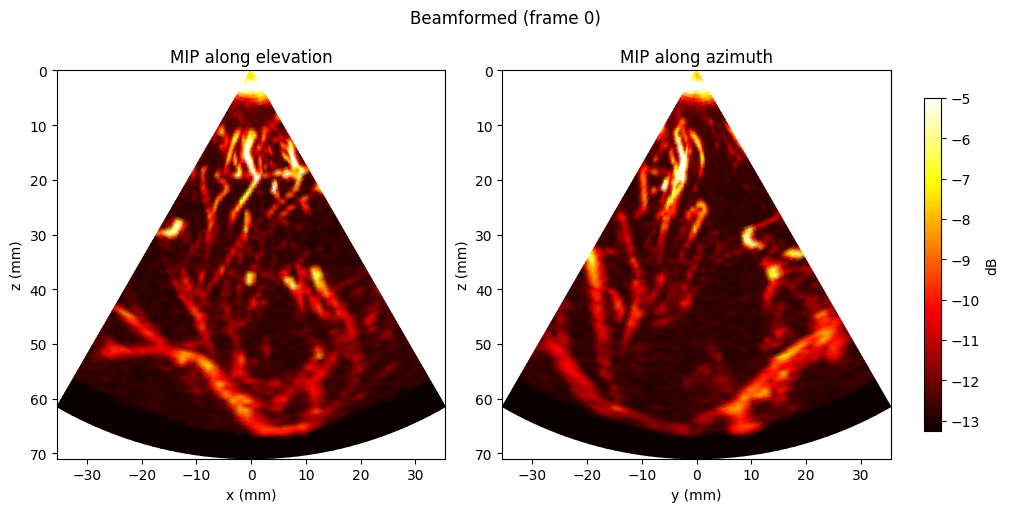

In [7]:
# ── Plot beamformed result ─────────────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display as ipy_display

with h5py.File(output_file, "r") as f:
    bf = np.abs(f["beamformed_data"][()])

# (nframes, nrho, nphi, ntheta) — optionally ensemble frames before log compression,
# then normalise dB to global max; voxels with zero amplitude (outside the acoustic
# FOV) become NaN so they are excluded from MIP computations.
vol_all = bf.reshape(bf.shape[0], *imgsize_tuple)
if vtk_ensemble_size > 1:
    n = vol_all.shape[0]
    n_ens = (n + vtk_ensemble_size - 1) // vtk_ensemble_size
    vol_all = vol_all[:n_ens * vtk_ensemble_size].reshape(n_ens, vtk_ensemble_size, *imgsize_tuple).mean(axis=1)
global_max = vol_all.max()
with np.errstate(divide='ignore', invalid='ignore'):
    vol_all = np.where(vol_all > 0, 20 * np.log10(vol_all / global_max), np.nan)

# colour range
vmin_global, vmax_global = np.nanpercentile(vol_all, [50, 99])

display_rotation_deg = 45 if dataset == "SpinningDisk" else 0.0
theta_rot = np.deg2rad(display_rotation_deg)

x_mm = grid_points[..., 0] * 1e3
y_mm = grid_points[..., 1] * 1e3
z_mm = grid_points[..., 2] * 1e3

x_disp_mm = np.cos(theta_rot) * x_mm - np.sin(theta_rot) * y_mm
y_disp_mm = np.sin(theta_rot) * x_mm + np.cos(theta_rot) * y_mm

is_2d = sum(d == 1 for d in imgsize_tuple) >= 1

def plot_frame(frame_idx):
    vol = vol_all[frame_idx]
    frame_label = f"frame {frame_idx}"

    if is_2d:
        squeezed = vol.squeeze()
        kept = [i for i, d in enumerate(imgsize_tuple) if d > 1]
        if len(kept) == 1:
            kept_ax = kept[0]
            coords = [z_mm, y_disp_mm, x_disp_mm]
            labels = ["z (mm)", "y (mm)", "x (mm)"]
            c = coords[kept_ax].squeeze()
            fig, ax = plt.subplots()
            ax.plot(c, squeezed)
            ax.set_xlabel(labels[kept_ax])
            ax.set_ylabel("Amplitude (dB)")
            ax.set_title(f"Beamformed ({frame_label})")
            plt.show()
        else:
            singleton_ax = [i for i, d in enumerate(imgsize_tuple) if d == 1][0]
            if singleton_ax == 1:
                h_label, h = "x (mm)", np.take(x_disp_mm, 0, axis=1)
            elif singleton_ax == 2:
                h_label, h = "y (mm)", np.take(y_disp_mm, 0, axis=2)
            else:
                h_label, h = "x (mm)", np.take(x_disp_mm, 0, axis=0)
            v_coords = np.take(z_mm, 0, axis=singleton_ax)
            if singleton_ax == 0:
                v_coords = np.take(y_disp_mm, 0, axis=0)
            fig, ax = plt.subplots(figsize=(6, 6))
            im = ax.pcolormesh(h, v_coords, squeezed, shading="gouraud", cmap="hot",
                               vmin=vmin_global, vmax=vmax_global)
            ax.set_aspect("equal")
            ax.invert_yaxis()
            ax.set_xlabel(h_label)
            ax.set_ylabel("z (mm)")
            ax.set_title(f"Beamformed ({frame_label})")
            fig.colorbar(im, ax=ax, label="dB")
            plt.show()
    else:
        if display_rotation_deg != 0:
            from scipy.ndimage import rotate as ndimage_rotate
            vol_disp = ndimage_rotate(vol, display_rotation_deg, axes=(2, 1),
                                      reshape=False, mode='constant', cval=np.nan)
        else:
            vol_disp = vol
        mip_phi   = np.nanmax(vol_disp, axis=1)
        mip_theta = np.nanmax(vol_disp, axis=2)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

        center_phi = imgsize_tuple[1] // 2
        im1 = axes[0].pcolormesh(
            x_disp_mm[:, center_phi, :], z_mm[:, center_phi, :], mip_phi,
            shading="gouraud", cmap="hot", vmin=vmin_global, vmax=vmax_global)
        axes[0].set_xlabel("x (mm)")
        axes[0].set_ylabel("z (mm)")
        axes[0].set_title("MIP along elevation")
        axes[0].set_aspect("equal")
        axes[0].invert_yaxis()

        center_theta = imgsize_tuple[2] // 2
        im2 = axes[1].pcolormesh(
            y_disp_mm[:, :, center_theta], z_mm[:, :, center_theta], mip_theta,
            shading="gouraud", cmap="hot", vmin=vmin_global, vmax=vmax_global)
        axes[1].set_xlabel("y (mm)")
        axes[1].set_ylabel("z (mm)")
        axes[1].set_title("MIP along azimuth")
        axes[1].set_aspect("equal")
        axes[1].invert_yaxis()

        title = f"Beamformed ({frame_label})"
        if display_rotation_deg != 0:
            title += f" — display rotated {display_rotation_deg:.0f}° about z-axis"
        fig.suptitle(title, y=1.02)

        fig.colorbar(im2, ax=axes.tolist(), fraction=0.02, pad=0.04, label="dB")
        plt.show()

if vol_all.shape[0] > 1:
    widgets.interact(plot_frame,
                     frame_idx=widgets.IntSlider(min=0, max=vol_all.shape[0] - 1,
                                                 step=1, value=0, description="Frame"))
else:
    plot_frame(0)


In [8]:
# ── Optional VTK export ───────────────────────────────────────────────────────
if save_vtk:
    with h5py.File(output_file, "r") as f:
        all_data = np.abs(f["beamformed_data"][()])

    all_data = 20 * np.log10(all_data / np.max(all_data))  # convert to dB

    vtk_dir  = output_file.parent / output_file.stem
    pvd_path = save_vtk_timeseries(
        frames        = all_data,
        imgsize       = imgsize_tuple,
        grid_points   = grid_points,
        output_dir    = vtk_dir,
        ensemble_size = vtk_ensemble_size,
    )
    print(f"VTK files saved to: {vtk_dir}")

    print(f"PVD collection:     {pvd_path}")


Saving VTK: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.41it/s]

VTK files saved to: results/HumanBrain/widebeam_beamformed_svd
PVD collection:     results/HumanBrain/widebeam_beamformed_svd.pvd


In [ ]:
# ── Visualize transmit/receive fields. (Optional) ─────────────────────────────────────────
%matplotlib inline
# ── Receive focus delays: 4×4 azimuth/elevation grid at 50 mm depth ──────────
# Angles: −22.5°, −7.5°, +7.5°, +22.5°  (15° steps, 4 values each axis → 16 points)
focus_angles_deg = np.array([-22.5, -7.5, 7.5, 22.5], dtype=np.float32)
focus_depth_m    = 60 # mm  #  -0.0328

# 4×4 grid of (theta=azimuth, phi=elevation) focus directions
theta_grid, phi_grid = np.meshgrid(focus_angles_deg, focus_angles_deg, indexing='xy')  # (4, 4)
theta_flat = np.deg2rad(theta_grid.ravel())                    # (16,)
phi_flat   = np.deg2rad(phi_grid.ravel())                      # (16,)

# Cartesian focus positions at 50 mm depth  →  (16, 3)
focus_xyz = sph2cart(
    theta_flat, phi_flat,
    np.full(len(theta_flat), focus_depth_m, dtype=np.float32),
).T  # sph2cart returns (3, N), transpose to (N, 3)

# Subaperture centre positions: mean of element positions within each subaperture  →  (n_subapertures, 3)
subap_centers = element_position.reshape(n_subapertures, subap_size, 3).mean(axis=1)

# focused_delays(focus, element_position, sound_speed) → (n_focus, n_elements)
# Here we treat subaperture centres as the "elements" to get one delay per subaperture.
# Result shape: (16, n_subapertures)
rx_focus_delays = focused_delays(focus_xyz, subap_centers, sound_speed)

# Uses the grid and delays from the parameter cell above.
# receive_focus_delay focuses each of the 16 receive beams at its grid point.

fwd_3d, rev_3d = plot_matched_filter_fields(
    xpos=voxel_position.reshape(-1, 3),
    ypos=element_position,
    frequency=frequencies,
    sound_speed=sound_speed,
    transmit_delay=tx_delays,
    receive_delay=rx_delays,
    transmit_apod=tx_apod,
    receive_apod=rx_apod,
    receive_focus_delay=rx_focus_delays,  # (16, n_subapertures) — one row per focus point
    imgsize=imgsize,
    grid_points=grid_points,
    batchsize=(16384, 4),
    device="cuda",
    waves=[8, 9, 10, 11],           # plot the first 4 transmit events
    plot_to=None,  # None → show on screen; or e.g. Path("fields.png") to save
)

print(f"Forward field shape: {fwd_3d.shape}")
print(f"Reverse field shape: {rev_3d.shape}")